# Toroidal VAE
### Template Space S¹x...xS¹

In [968]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [969]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Imports

In [970]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders.synthetic_loader as dataloader
import lib.models.vae.vm_toroidal_vae as model
import lib.trainer as trainer
import lib.utils as utils

from types import SimpleNamespace



### General set up

In [971]:
# Set random seed for reproducibility
torch.manual_seed(59)
np.random.seed(49)

### Experiment Configurations

In [972]:
loader_config = {
    "dataset_name": "s1_synthetic",
    "batch_size": 128,
    "synthetic_rotation": "random",
    "n_times": 10000,
    "radius": 2.0,
    "n_wiggles": 6,
    "geodesic_distortion_amp": 0.1,
    "embedding_dim": 3,
    "noise_var": 0.0001,
    "geodesic_distortion_func": "wiggles",
    "plot_dataset": True
}

model_config = {
    'data_dim': loader_config["embedding_dim"],
    'latent_dim': 1,
    'sftbeta': 3.5,
    'device': "cpu",
    'encoder_widths': [5],
    'decoder_widths': [30,10,10,10,10],
}

trainer_config = {
    'num_epochs': 20,
    'log_interval': 100,
    'device': "cpu",
    'recon_loss': "MSE",
    'beta': 0.01,  # weight for KL loss 
}

curvature_config = {
    "n_grid_points": 2000,  # to compute curvature
    "manifold_dim": 1,
}

config_dict = {}
config_dict.update(loader_config)
config_dict.update(model_config)
config_dict.update(trainer_config)
config_dict.update(curvature_config)

config = SimpleNamespace(**config_dict)

 ### Dataloader

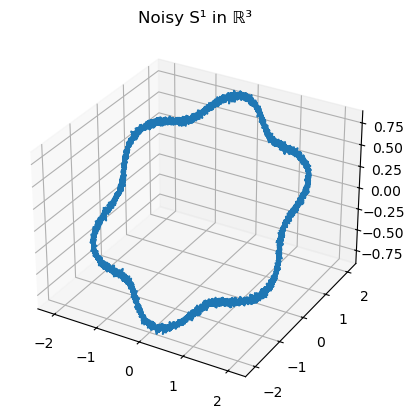

In [973]:
dataloader = dataloader.load_synthetic_ds(loader_config)
train_loader, test_loader = dataloader

### Model

In [974]:
toroidal_model = model.VMToroidalVAE(model_config)

### Optimizer

In [975]:
learning_rate = 0.001

toroidal_optimizer = optim.Adam(toroidal_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [976]:
toroidal_history = trainer.MVAETrainer(toroidal_model, dataloader, toroidal_optimizer, config).train()

Trainer successfully initialized.
Training the vm_toroidalVAE model.
Starting epoch 1/20
Epoch 1/20, Train Loss: 4.4563, Test Loss: 4.0889
--------------------------------------------------
Starting epoch 2/20
Epoch 2/20, Train Loss: 3.9615, Test Loss: 3.8976
--------------------------------------------------
Starting epoch 3/20
Epoch 3/20, Train Loss: 3.8456, Test Loss: 3.7824
--------------------------------------------------
Starting epoch 4/20
Epoch 4/20, Train Loss: 3.7149, Test Loss: 3.7005
--------------------------------------------------
Starting epoch 5/20
Epoch 5/20, Train Loss: 3.6652, Test Loss: 3.6103
--------------------------------------------------
Starting epoch 6/20
Epoch 6/20, Train Loss: 3.5546, Test Loss: 3.4889
--------------------------------------------------
Starting epoch 7/20
Epoch 7/20, Train Loss: 3.4387, Test Loss: 3.3662
--------------------------------------------------
Starting epoch 8/20
Epoch 8/20, Train Loss: 3.3235, Test Loss: 3.2327
--------------

### Visualization 

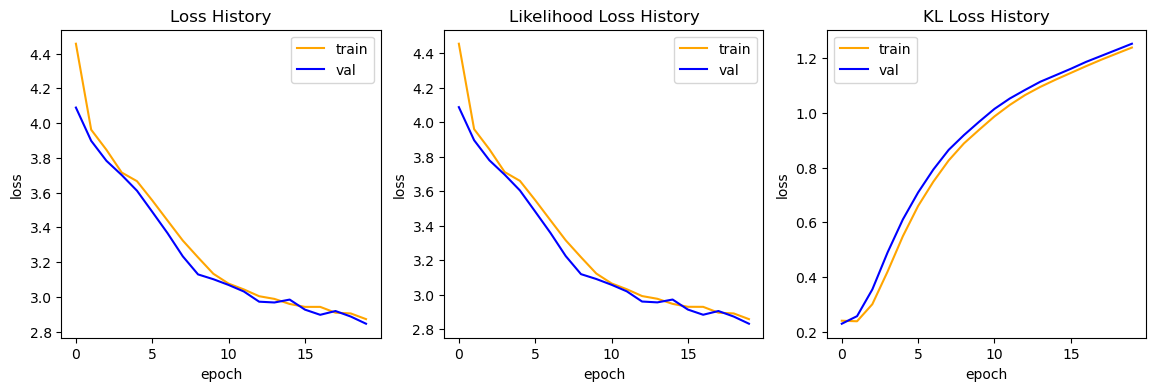

In [977]:
utils.show_training_history(toroidal_history)

#### Plot latent space

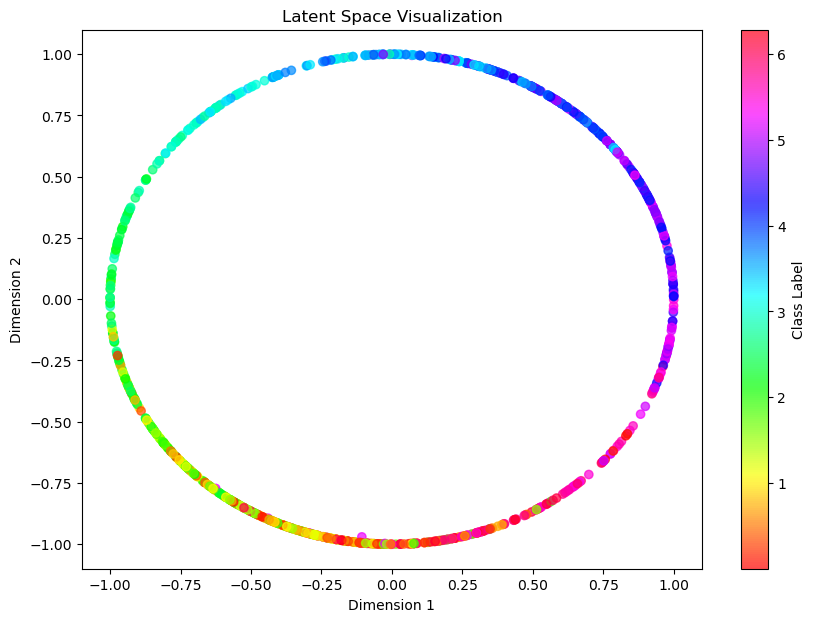

In [978]:
utils.plot_euclidean_latent_space(toroidal_model, test_loader, n_samples=10000)

### Plot reconstructed manifold

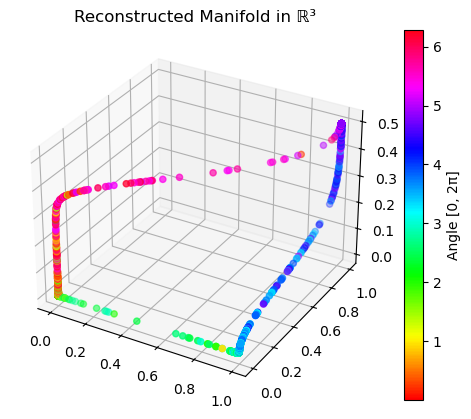

In [979]:
utils.plot_recon_manifold(toroidal_model, test_loader, n_samples=1000)

#### Compute curvature error

Computing learned curvature...
Computation time: 23.108 s
Computing true curvature for synthetic data...
Computation time: 14.812 s
Computing curvature error for synthetic data...


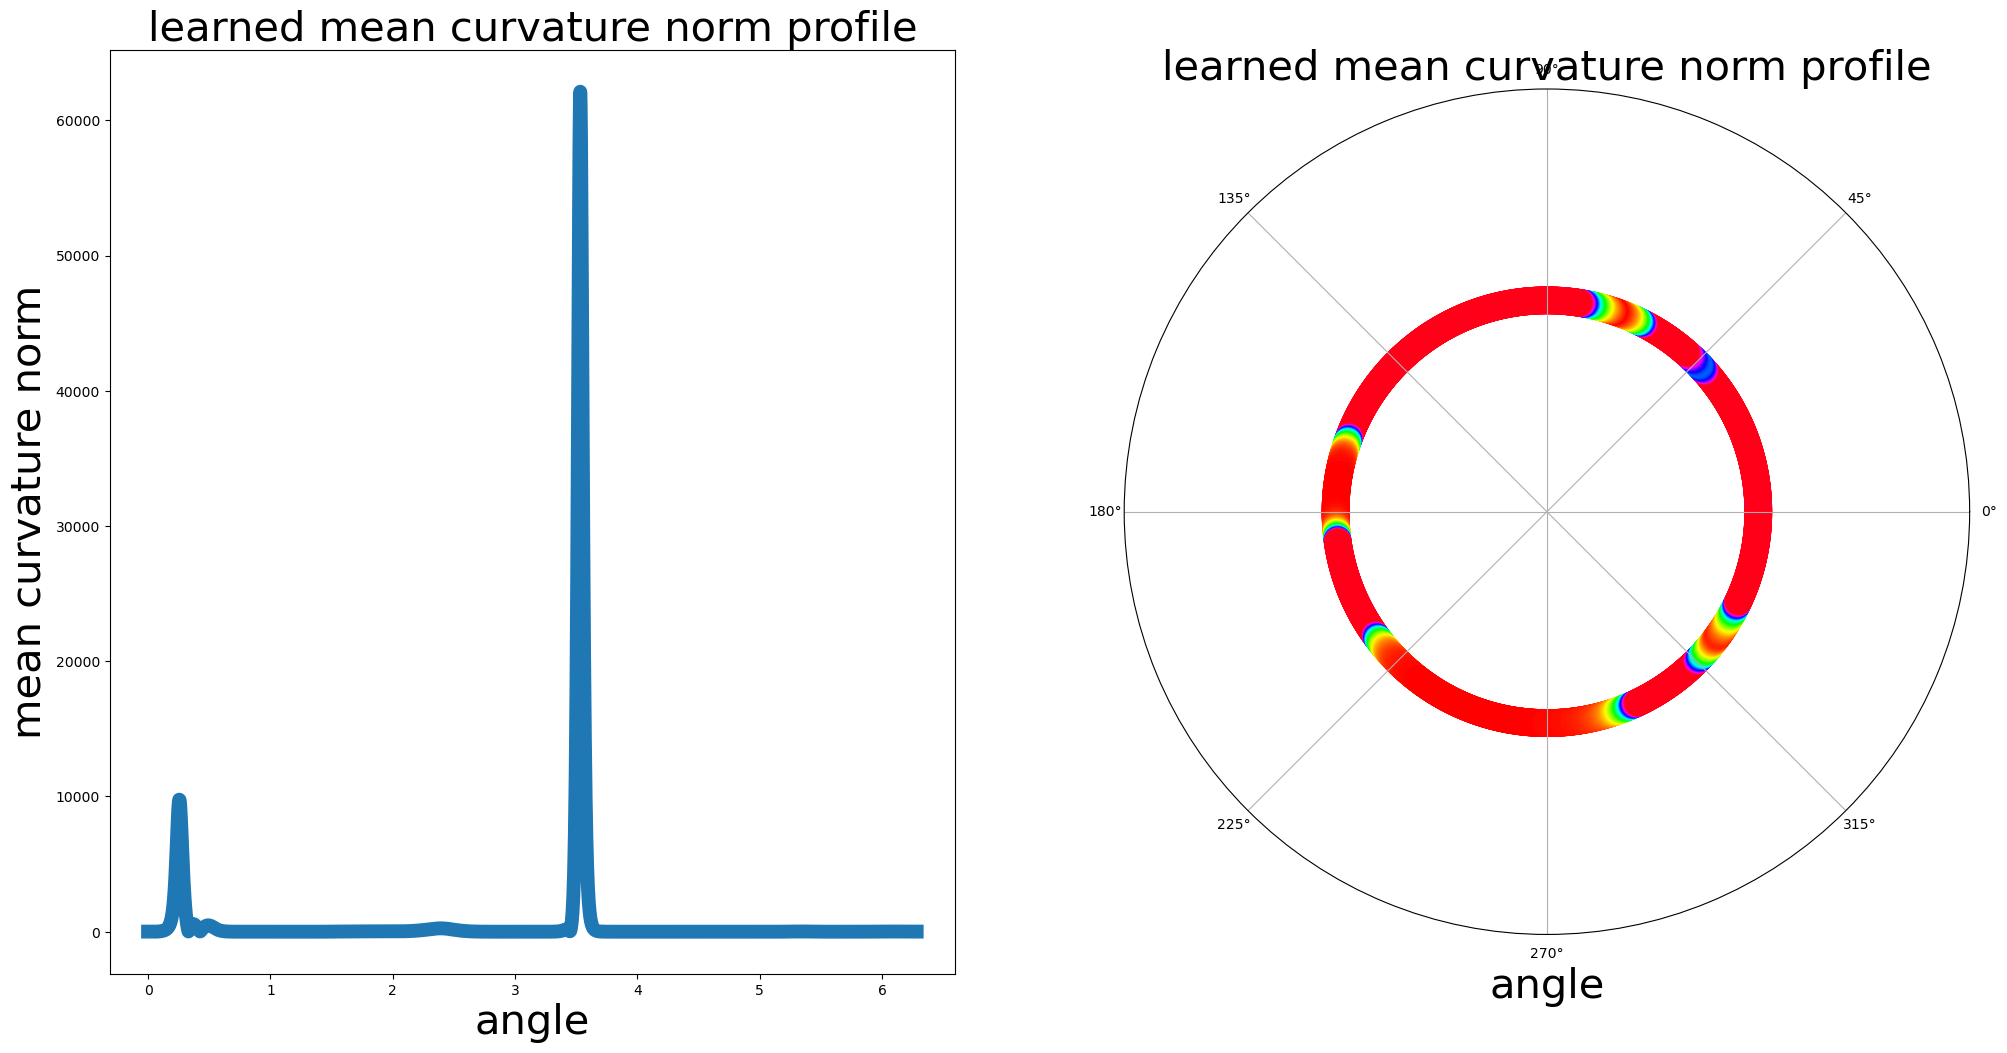

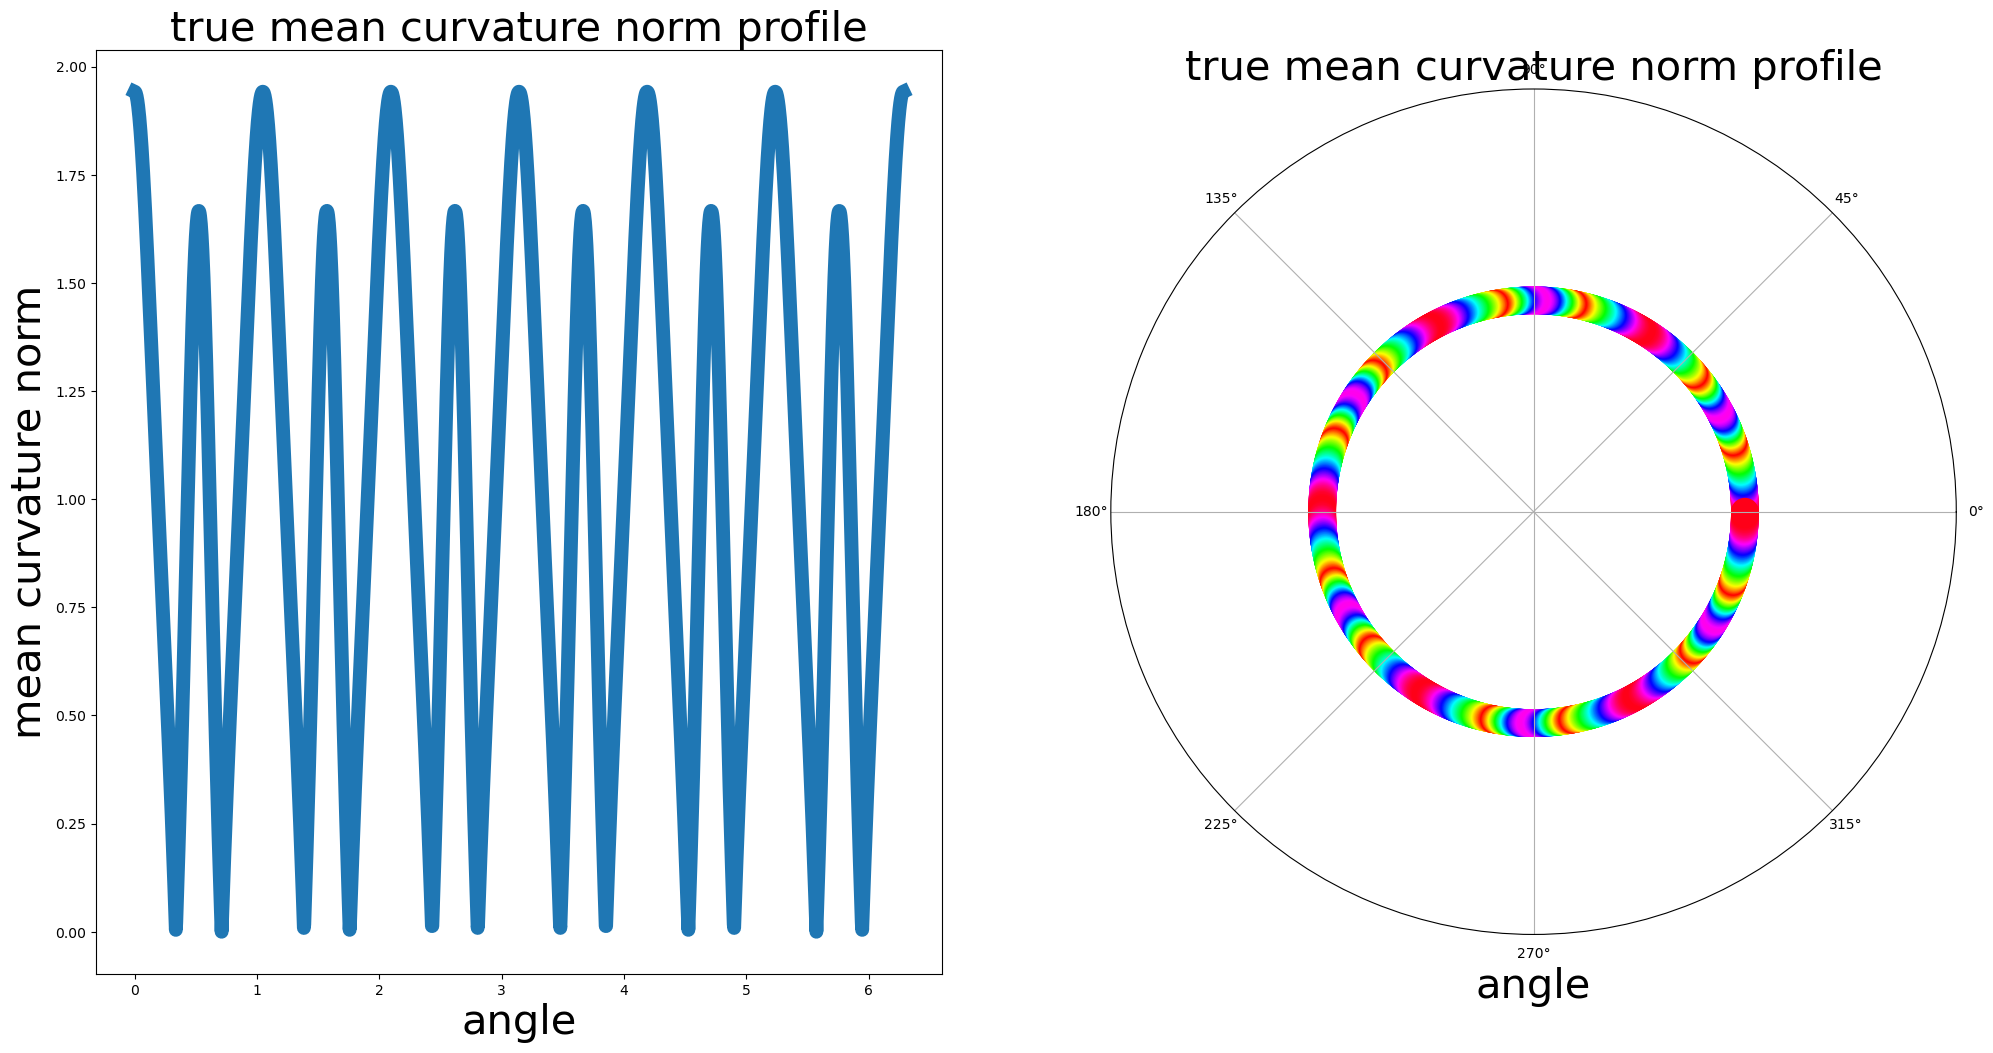

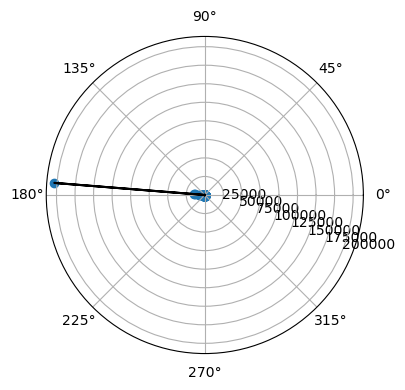

In [980]:
all_data = []
all_labels = []

for data, labels in test_loader:
    all_data.append(data)
    all_labels.append(labels)

all_data = torch.cat(all_data)
all_labels = torch.cat(all_labels)

utils.curvature_compute_plot(config, all_data, all_labels, toroidal_model)

### Save trained models

In [981]:
#modelutils.save_model(toroidal_model, model_config)

### Load pretrained models

In [982]:
#model = modelutils.load_model("gaussian_1740054584")
#model = toroidal_model